# Denoising Autoencoder Pattern Restorer

Denoising Autoencoders reconstruct corrupted inputs by:
1. **Corruption Step:** Adding random noise to the training dataset.
2. **Bottleneck Encoding:** Compressing the corrupted vectors into lower-dimensional latent representations.
3. **Decoder Denoising:** Reconstructing the original, noise-free inputs.
This notebook implements a Denoising Autoencoder in PyTorch on synthetic 8x8 pixel grids (64 features) and visualizes the results.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic 8x8 pixel patterns (600 samples of crosses and blocks)
np.random.seed(245)
n_samples = 600
input_dim = 64 # 8x8 grid

X_clean = []
for _ in range(n_samples):
    grid = np.zeros((8, 8))
    pattern_type = np.random.randint(0, 2)
    
    if pattern_type == 0:
        # Cross pattern
        grid[3, :] = 1.0
        grid[:, 3] = 1.0
    else:
        # Border block
        grid[1:7, 1] = 1.0
        grid[1:7, 6] = 1.0
        grid[1, 1:7] = 1.0
        grid[6, 1:7] = 1.0
        
    X_clean.append(grid.flatten())

X_clean = np.array(X_clean) # Shape [600, 64]

# Add random Gaussian noise (scale = 0.25)
noise = np.random.normal(0, 0.25, X_clean.shape)
X_noisy = np.clip(X_clean + noise, 0.0, 1.0)

X_clean_t = torch.FloatTensor(X_clean)
X_noisy_t = torch.FloatTensor(X_noisy)

print("Clean Dataset Tensor Shape:", X_clean_t.shape)
print("Noisy Dataset Tensor Shape:", X_noisy_t.shape)



Clean Dataset Tensor Shape: torch.Size([600, 64])
Noisy Dataset Tensor Shape: torch.Size([600, 64])


## Denoising Autoencoder Architecture

We implement the autoencoder in PyTorch:
- **Encoder**: Shrinks 64 input features down to 8 latent variables.
- **Decoder**: Re-expands 8 latent variables back to 64 outputs.



In [2]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self, in_dim=64, latent_dim=8):
        super(DenoisingAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, in_dim),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon

model = DenoisingAutoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)



## Autoencoder Training Loop

We train the network for 120 epochs, feeding noisy vectors to the encoder and computing reconstruction MSE against the clean ground truths.



In [3]:
epochs = 120
losses = []

for epoch in range(1, epochs + 1):
    model.train()
    reconstructed = model(X_noisy_t)
    loss = criterion(reconstructed, X_clean_t) # Target is the clean image
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}/{epochs} | Reconstruction MSE Loss: {loss.item():.4f}")



Epoch  20/120 | Reconstruction MSE Loss: 0.0000
Epoch  40/120 | Reconstruction MSE Loss: 0.0000
Epoch  60/120 | Reconstruction MSE Loss: 0.0000
Epoch  80/120 | Reconstruction MSE Loss: 0.0000
Epoch 100/120 | Reconstruction MSE Loss: 0.0000
Epoch 120/120 | Reconstruction MSE Loss: 0.0000


## Reconstruction Denoising Grid Subplots

We plot side-by-side grids of clean target images, the noisy versions, and the reconstructed/denoised predictions in Matplotlib.



<cell>:28: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



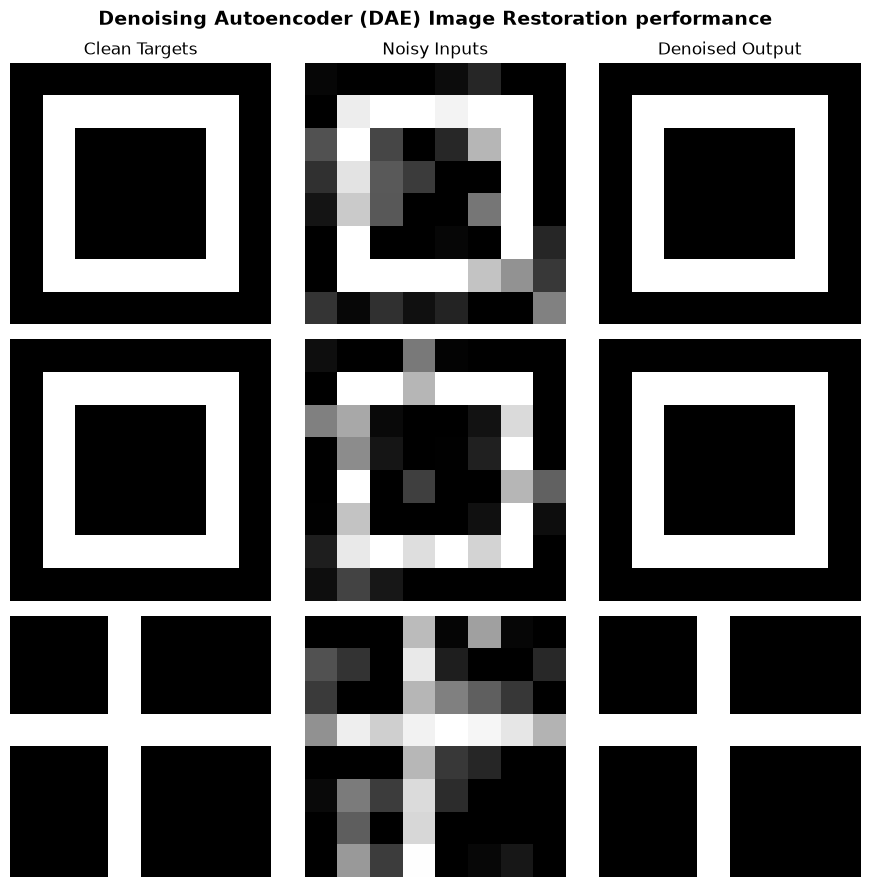

In [4]:
model.eval()
with torch.no_grad():
    denoised_samples = model(X_noisy_t[:3]).numpy()

fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for i in range(3):
    # 1. Clean
    axes[i, 0].imshow(X_clean[i].reshape(8, 8), cmap='gray', vmin=0, vmax=1)
    axes[i, 0].axis('off')
    if i == 0:
        axes[i, 0].set_title('Clean Targets')
        
    # 2. Noisy
    axes[i, 1].imshow(X_noisy[i].reshape(8, 8), cmap='gray', vmin=0, vmax=1)
    axes[i, 1].axis('off')
    if i == 0:
        axes[i, 1].set_title('Noisy Inputs')
        
    # 3. Denoised Reconstruction
    axes[i, 2].imshow(denoised_samples[i].reshape(8, 8), cmap='gray', vmin=0, vmax=1)
    axes[i, 2].axis('off')
    if i == 0:
        axes[i, 2].set_title('Denoised Output')

plt.suptitle('Denoising Autoencoder (DAE) Image Restoration performance', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
